# Lesson 10.1 - Robotics & Control Foundations (toy control demo)

## Objectives

- Simulate 1D motion control with PID.
- Compare gain settings using response plots.
- Connect overshoot and settling time to tuning choices.


In [1]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)


## 1D Point-Mass Setup

State variables:

- position x
- velocity v

Control input u acts like acceleration command.


In [2]:
def simulate_pid(Kp: float, Ki: float, Kd: float, target: float = 1.0, T: float = 8.0, dt: float = 0.01):
    n = int(T / dt)
    x = 0.0
    v = 0.0
    integral = 0.0
    prev_error = target - x

    xs, vs, us, ts = [], [], [], []

    for i in range(n):
        t = i * dt
        error = target - x
        integral += error * dt
        derivative = (error - prev_error) / dt
        u = Kp * error + Ki * integral + Kd * derivative

        # simple damped point-mass dynamics: x'' = u - c*v
        c = 0.6
        a = u - c * v
        v += a * dt
        x += v * dt

        prev_error = error
        ts.append(t)
        xs.append(x)
        vs.append(v)
        us.append(u)

    return np.array(ts), np.array(xs), np.array(vs), np.array(us)


## Compare Gain Settings


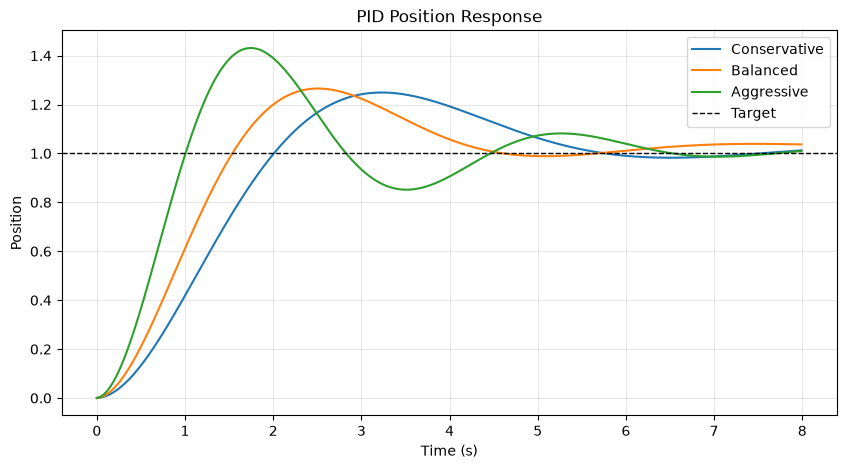

In [3]:
configs = {
    "Conservative": (1.2, 0.05, 0.4),
    "Balanced": (2.0, 0.15, 0.7),
    "Aggressive": (3.5, 0.25, 0.5),
}

target = 1.0
results = {}
for name, (kp, ki, kd) in configs.items():
    results[name] = simulate_pid(kp, ki, kd, target=target)

plt.figure(figsize=(10, 5))
for name, (t, x, _, _) in results.items():
    plt.plot(t, x, label=name)
plt.axhline(target, color='black', linestyle='--', linewidth=1, label='Target')
plt.xlabel('Time (s)')
plt.ylabel('Position')
plt.title('PID Position Response')
plt.grid(alpha=0.3)
plt.legend()
plt.show()


In [4]:
def settling_time(t, x, target, tol=0.02):
    lower, upper = target * (1 - tol), target * (1 + tol)
    for i in range(len(x)):
        if np.all((x[i:] >= lower) & (x[i:] <= upper)):
            return t[i]
    return np.nan

for name, (t, x, v, u) in results.items():
    overshoot = max(0.0, x.max() - target)
    st = settling_time(t, x, target)
    print(f"{name}: overshoot={overshoot:.3f}, settling_time={st:.2f}s")


Conservative: overshoot=0.249, settling_time=5.46s
Balanced: overshoot=0.265, settling_time=nans
Aggressive: overshoot=0.431, settling_time=6.24s


## Connect to Theory

- High proportional gain speeds response but can increase overshoot.
- Integral term removes bias but may destabilize if too strong.
- Derivative term adds damping and reduces oscillation.

These same phenomena appear in actuator loops for drones, mobile bases, and manipulators.


## Business Case Studies & Exceptions

### Case A: Warehouse AMR Wheel Control

A mobile robot uses feedback loops to track wheel velocity despite floor friction changes and payload variation. Conservative tuning reduces oscillation near docking stations.

### Case B: Industrial Arm Joint Control

Joint-level PID loops execute repeated trajectories. Gains are tuned per joint because load and inertia differ across axes.

### Exceptions

- For highly nonlinear fast dynamics, advanced model-based or adaptive controllers may outperform plain PID.
- For safety-critical systems, simple predictable controllers may still be preferred over learned controllers.


## Interview Questions & Answers

1. **Q: What is feedback control?**
   **A:** Continuous correction based on measured error between desired and actual state.
2. **Q: What does PID stand for?**
   **A:** Proportional, Integral, Derivative.
3. **Q: Why does high Kp cause overshoot?**
   **A:** Strong immediate correction can push state beyond target before damping catches up.
4. **Q: What does Ki fix?**
   **A:** Persistent steady-state error.
5. **Q: What is derivative action useful for?**
   **A:** Damping rapid changes and reducing oscillations.
6. **Q: What is settling time?**
   **A:** Time for response to remain within tolerance of target.
7. **Q: What is integral windup?**
   **A:** Excess integral accumulation that causes large corrective bursts.
8. **Q: How would you tune PID quickly?**
   **A:** Increase Kp to responsiveness, add Kd for damping, then Ki for bias removal.
9. **Q: Where is PID used in robotics?**
   **A:** Motor velocity/position loops, gimbals, attitude loops, process actuators.
10. **Q: When is PID insufficient?**
   **A:** In strongly nonlinear or highly coupled systems needing advanced control methods.
